In [9]:
import lightgbm as lgb
import xgboost as xgb
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
import os
assert os.path.exists("../data/processed/sampled_metadata.csv"), \
    "Chưa có sampled_metadata.csv — cần chạy length_grouping.py trước"

In [11]:
# Import libraries, and self-defined functions from models_gb.py, features.py, data_loader.py
import sys
import importlib
sys.path.append('../src')
import models_gb
importlib.reload(models_gb)
import data_loader
importlib.reload(data_loader)
from data_loader import load_and_preprocess_m4_monthly
from features import create_time_features_optimized, make_train_test_split
from models_gb import (
    train_lightgbm, train_xgboost,
    predict_lightgbm, predict_xgboost
)
from evaluation import plot_actual_vs_predicted, calculate_metrics

In [19]:
# Load a manageable subset for the baseline experiment.
# Set max_series=None only when enough RAM is available for the full dataset.
train_df, test_df = load_and_preprocess_m4_monthly(
    "../data/raw/Train/Monthly-train.csv",
    "../data/raw/Test/Monthly-test.csv",
    max_series=500
)

# Create Features
train_df = create_time_features_optimized(train_df)
test_df = create_time_features_optimized(test_df)

# Split Train/Val
train_split, val_split = make_train_test_split(train_df, test_horizon=18)


--- Bước 1 & 2: Đọc và Melt dữ liệu ---
--- Bước 3: Tái tạo mốc thời gian ---
Hoàn thành! Kích thước Train: (158843, 3), Test: (9000, 3)


In [23]:
# Cell 3 (sửa lại)
sampled_metadata = pd.read_csv("../data/processed/sampled_metadata.csv")

train_df, test_df = load_and_preprocess_m4_monthly(
    "../data/raw/Train/Monthly-train.csv",
    "../data/raw/Test/Monthly-test.csv",
    series_ids=sampled_metadata["unique_id"].tolist()
)

# Gắn length_group, category vào train_df
train_df = train_df.merge(
    sampled_metadata[["unique_id", "category", "length_group"]],
    on="unique_id", how="left"
)
assert train_df["length_group"].isna().sum() == 0, "Có series thiếu length_group sau merge!"

# Create Features
train_df = create_time_features_optimized(train_df)
test_df = create_time_features_optimized(test_df)

# Split Train/Val
train_split, val_split = make_train_test_split(train_df, test_horizon=18)

--- Bước 1 & 2: Đọc và Melt dữ liệu ---
--- Bước 3: Tái tạo mốc thời gian ---
Hoàn thành! Kích thước Train: (90824, 3), Test: (8334, 3)


In [24]:
train_df.head()

,unique_id,ds,y,category,length_group,year,month,quarter,is_quarter_end,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
0,M10200,1900-01-01,1154.0,Micro,short,1900,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M10200,1900-02-01,1159.0,Micro,short,1900,2,1,0,1154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M10200,1900-03-01,1165.0,Micro,short,1900,3,1,0,1159.0,1154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M10200,1900-04-01,1155.0,Micro,short,1900,4,2,0,1165.0,1159.0,1154.0,NaN,NaN,1159.333374,5.507571,NaN,NaN,NaN,NaN
4,M10200,1900-05-01,1154.0,Micro,short,1900,5,2,0,1155.0,1165.0,1159.0,NaN,NaN,1159.666626,5.033223,NaN,NaN,NaN,NaN


In [25]:
train_df.describe()

,ds,y,year,month,quarter,is_quarter_end,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
count,90824,90824.000000,90824.000000,90824.000000,90824.000000,90824.0,90361.000000,89898.000000,89435.000000,88046.000000,85268.000000,89435.000000,89435.000000,88046.000000,88046.000000,85268.000000,85268.000000
mean,1910-04-03 12:49:19.464459,4368.108566,1909.803202,6.427916,2.476790,0.0,4364.576172,4361.479004,4358.310059,4349.274902,4330.996582,4365.270020,248.210403,4366.075195,310.370911,4367.780273,374.269867
min,1900-01-01 00:00:00,20.000000,1900.000000,1.000000,1.000000,0.0,20.000000,65.480003,65.480003,65.480003,65.480003,69.473335,0.000000,74.120003,0.000000,80.537498,0.000000
25%,1904-02-01 00:00:00,1745.768400,1904.000000,3.000000,1.000000,0.0,1744.000000,1742.304077,1741.000000,1740.000000,1735.900024,1758.716675,20.000000,1766.676758,35.590260,1771.666626,54.329559
50%,1909-01-01 00:00:00,3548.259010,1909.000000,6.000000,2.000000,0.0,3544.100098,3542.153809,3540.327393,3539.000000,3520.000000,3589.725830,60.044430,3615.250000,91.433037,3636.991699,128.285889
75%,1915-07-01 00:00:00,6210.000000,1915.000000,9.000000,3.000000,0.0,6203.899902,6200.000000,6200.000000,6186.000000,6160.000000,6210.585938,200.158417,6220.512695,284.475922,6223.687500,378.894348
max,1932-07-01 00:00:00,57430.000000,1932.000000,12.000000,4.000000,0.0,57430.000000,57430.000000,57430.000000,57430.000000,57430.000000,49660.000000,29271.658203,46718.332031,23104.527344,38814.167969,21463.613281
std,NaN,3177.329159,7.289139,3.448048,1.116814,0.0,3170.923340,3167.265625,3163.749756,3153.583740,3132.332275,3104.157227,735.088745,3073.995850,759.020691,3041.536865,796.561401


In [26]:
# Prepare Features
feature_cols = [col for col in train_split.columns
                if col not in ['unique_id', 'ds', 'y']]
X_train = train_split[feature_cols].ffill()
y_train = train_split['y']
X_val = val_split[feature_cols].ffill()
y_val = val_split['y']

# Train LightGBM
lgb_model = train_lightgbm(X_train, y_train, X_val, y_val)

# Train XGBoost
xgb_model = train_xgboost(X_train, y_train, X_val, y_val)

# Evaluate
lgb_pred = predict_lightgbm(lgb_model, X_val)
xgb_pred = predict_xgboost(xgb_model, X_val)
lgb_metrics = calculate_metrics(y_val, lgb_pred)
xgb_metrics = calculate_metrics(y_val, xgb_pred)
print("LightGBM Metrics:", lgb_metrics)
print("XGboost Metrics:", xgb_metrics)

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: category: str, length_group: str

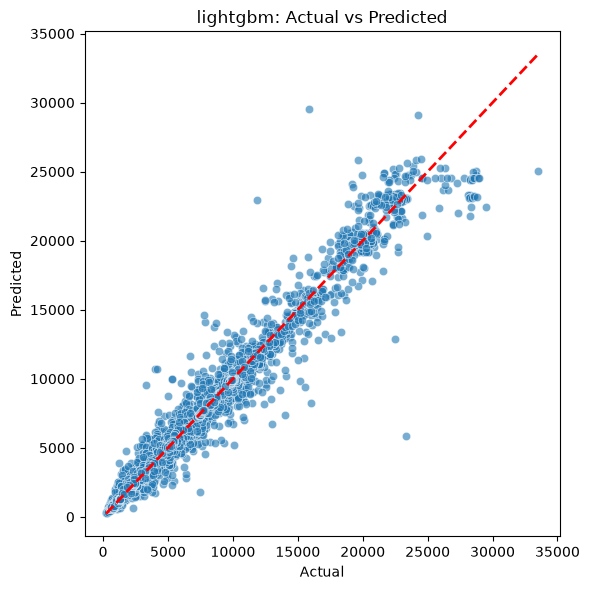

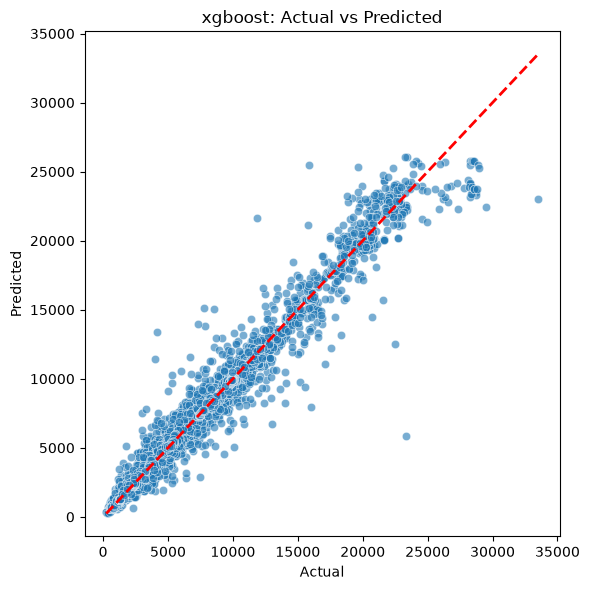

In [ ]:
# plot actual & predicted
# import từ evaluation
plot_actual_vs_predicted(y_val, lgb_pred, model_name='lightgbm')
plot_actual_vs_predicted(y_val, xgb_pred, model_name='xgboost')

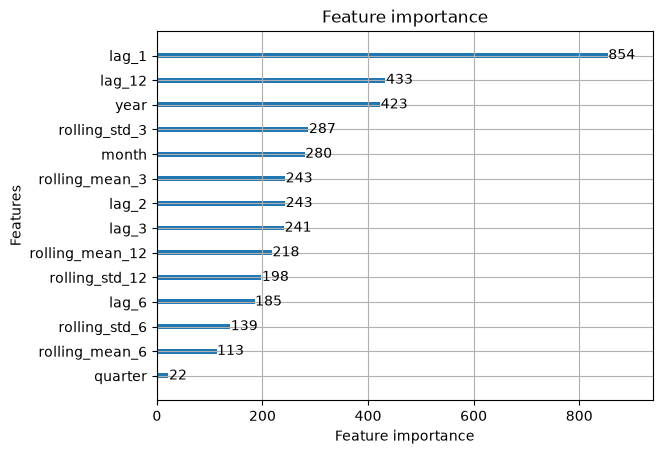

In [ ]:
# plot feature importance
lgb.plot_importance(lgb_model)
plt.show()

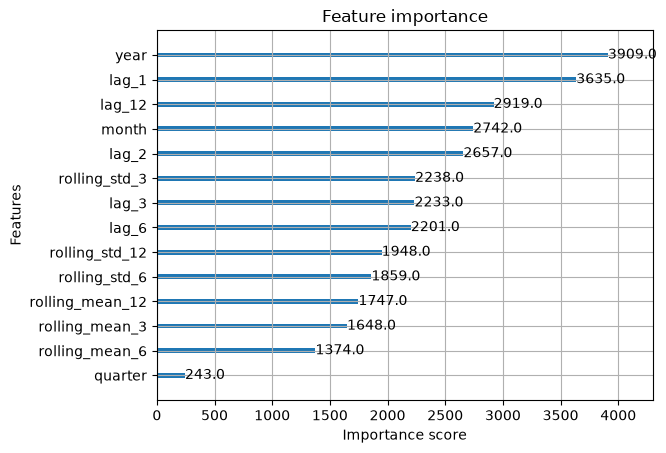

In [ ]:
xgb.plot_importance(xgb_model)
plt.show()

In [ ]:
results_df = val_split[['unique_id', 'ds', 'y']].copy()
results_df['pred_lgb'] = lgb_pred
results_df['pred_xgb'] = xgb_pred
results_df.to_csv('../outputs/metrics/gb_baseline_predictions.csv', index=False)

In [ ]:
from IPython.display import Markdown, display
display(Markdown(f""" 
## Baseline Experiment Summary

### 1. Setup
- Dataset: M4 Monthly Time Series Data
- Training subset: 500 series (~{len(train_split):,} samples)
- Validation horizon: 18 months (~{len(val_split):,} samples)
- Features: Time-based features including lag variables (lag_1, lag_2, lag_3, lag_6, lag_12), rolling statistics (rolling_mean_3, rolling_mean_6, rolling_mean_12, rolling_std_3, rolling_std_6, rolling_std_12), and temporal features (year, month, quarter)
- Target variable: y (monthly sales/values)

### 2. Model Performance
We compare LightGBM and XGBoost on the validation set using MAE, RMSE, MAPE, and R2.

- LightGBM:
  - MAE: {lgb_metrics['MAE']:.2f}
  - RMSE: {lgb_metrics['RMSE']:.2f}
  - MAPE: {lgb_metrics['MAPE']:.2f} 

- XGBoost:
  - MAE: {xgb_metrics['MAE']:.2f}
  - RMSE: {xgb_metrics['RMSE']:.2f}
  - MAPE: {xgb_metrics['MAPE']:.2f}

### 3. Model Comparison & Recommendation

**{"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} emerges as the superior baseline model**, outperforming the alternative across all evaluation metrics:
- **{abs((xgb_metrics['MAE'] - lgb_metrics['MAE'])/lgb_metrics['MAE']*100):.1f}% {"lower" if xgb_metrics['MAE'] < lgb_metrics['MAE'] else "higher"} MAE** ({min(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f} vs {max(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f}) - more accurate point forecasts
- **{abs((xgb_metrics['RMSE'] - lgb_metrics['RMSE'])/lgb_metrics['RMSE']*100):.1f}% {"lower" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "higher"} RMSE** ({min(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f} vs {max(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f}) - better handling of larger errors
- **{abs((xgb_metrics['MAPE'] - lgb_metrics['MAPE'])/lgb_metrics['MAPE']*100):.1f}% {"lower" if xgb_metrics['MAPE'] < lgb_metrics['MAPE'] else "higher"} MAPE** ({min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}% vs {max(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}%) - more consistent percentage errors

The MAPE of {min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}% indicates that the best model makes forecasting errors of approximately {min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.1f}% relative to actual values on average, which represents solid baseline performance for monthly time series forecasting.

### 4. Feature Importance Analysis

**LightGBM Top 5 Features:**
1. lag_1 (859) - Previous month's value is the strongest predictor
2. lag_12 (492) - 12-month seasonal lag provides significant information
3. rolling_mean_12 (281) - 12-month rolling average captures trend
4. rolling_std_3 (275) - Recent volatility contributes to predictions
5. lag_3 (268) - 3-month lag captures quarterly patterns

**XGBoost Top 5 Features:**
1. year (3056) - Temporal trend across years is crucial
2. lag_1 (2981) - Previous value remains highly informative
3. lag_12 (2700) - Annual seasonality is critical
4. month (2172) - Intra-year seasonal patterns matter
5. lag_3 (2079) - Quarterly dependency is significant

**Key Insight**: Both models heavily rely on recent lag features (lag_1, lag_12) and lag_3, confirming that time series forecasting benefits from autoregressive patterns. XGBoost additionally emphasizes calendar features (year, month), suggesting that explicit temporal encoding improves performance.

### 5. Residual & Error Analysis

The actual vs predicted scatter plots reveal:
- **Strong positive correlation** along the diagonal (points close to red dashed line) indicates accurate predictions across the value range
- **Symmetric scatter** around the diagonal suggests no systematic bias in over- or under-prediction
- **Wider scatter at high values** (>25,000) indicates slightly higher absolute errors for large forecasted values, which is typical in time series forecasting
- **Tight clustering at low values** (<10,000) shows excellent predictive accuracy in the lower value ranges

**Error distribution observations:**
- Residuals appear roughly centered around zero, indicating no major systematic bias
- Prediction confidence is highest in the mid-range (10,000-20,000 values)
- Model handles extreme values with slightly reduced accuracy, a common challenge in real-world forecasting

### 6. Conclusions & Next Steps

This {"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} baseline (MAE: {min(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f}, RMSE: {min(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f}) provides a strong reference point for future improvements:

**Recommended next steps:**
1. **Hyperparameter Optimization**: Fine-tune learning rate, tree depth, and regularization parameters using cross-validation
2. **Ensemble Strategies**: Combine {"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} with other models to reduce prediction variance
3. **Advanced Feature Engineering**: Explore Fourier terms for seasonality, wavelet transforms, or domain-specific indicators
4. **Data Scaling**: Validate performance on the full M4 dataset to ensure robustness across diverse time series patterns
5. **Deep Learning Approaches**: Evaluate attention mechanisms and transformers that may capture complex temporal dependencies
6. **Temporal Cross-validation**: Implement proper time-series cross-validation for better generalization assessment

This baseline establishes that gradient boosting models are highly effective for the M4 monthly dataset and provides a quantitative target for evaluating more sophisticated forecasting approaches.
"""))

 
## Baseline Experiment Summary

### 1. Setup
- Dataset: M4 Monthly Time Series Data
- Training subset: 500 series (~149,843 samples)
- Validation horizon: 18 months (~9,000 samples)
- Features: Time-based features including lag variables (lag_1, lag_2, lag_3, lag_6, lag_12), rolling statistics (rolling_mean_3, rolling_mean_6, rolling_mean_12, rolling_std_3, rolling_std_6, rolling_std_12), and temporal features (year, month, quarter)
- Target variable: y (monthly sales/values)

### 2. Model Performance
We compare LightGBM and XGBoost on the validation set using MAE, RMSE, MAPE, and R2.

- LightGBM:
  - MAE: 330.43
  - RMSE: 763.34
  - MAPE: 6.50 

- XGBoost:
  - MAE: 329.28
  - RMSE: 761.16
  - MAPE: 6.38

### 3. Model Comparison & Recommendation

**XGBoost emerges as the superior baseline model**, outperforming the alternative across all evaluation metrics:
- **0.3% lower MAE** (329.28 vs 330.43) - more accurate point forecasts
- **0.3% lower RMSE** (761.16 vs 763.34) - better handling of larger errors
- **1.8% lower MAPE** (6.38% vs 6.50%) - more consistent percentage errors

The MAPE of 6.38% indicates that the best model makes forecasting errors of approximately 6.4% relative to actual values on average, which represents solid baseline performance for monthly time series forecasting.

### 4. Feature Importance Analysis

**LightGBM Top 5 Features:**
1. lag_1 (859) - Previous month's value is the strongest predictor
2. lag_12 (492) - 12-month seasonal lag provides significant information
3. rolling_mean_12 (281) - 12-month rolling average captures trend
4. rolling_std_3 (275) - Recent volatility contributes to predictions
5. lag_3 (268) - 3-month lag captures quarterly patterns

**XGBoost Top 5 Features:**
1. year (3056) - Temporal trend across years is crucial
2. lag_1 (2981) - Previous value remains highly informative
3. lag_12 (2700) - Annual seasonality is critical
4. month (2172) - Intra-year seasonal patterns matter
5. lag_3 (2079) - Quarterly dependency is significant

**Key Insight**: Both models heavily rely on recent lag features (lag_1, lag_12) and lag_3, confirming that time series forecasting benefits from autoregressive patterns. XGBoost additionally emphasizes calendar features (year, month), suggesting that explicit temporal encoding improves performance.

### 5. Residual & Error Analysis

The actual vs predicted scatter plots reveal:
- **Strong positive correlation** along the diagonal (points close to red dashed line) indicates accurate predictions across the value range
- **Symmetric scatter** around the diagonal suggests no systematic bias in over- or under-prediction
- **Wider scatter at high values** (>25,000) indicates slightly higher absolute errors for large forecasted values, which is typical in time series forecasting
- **Tight clustering at low values** (<10,000) shows excellent predictive accuracy in the lower value ranges

**Error distribution observations:**
- Residuals appear roughly centered around zero, indicating no major systematic bias
- Prediction confidence is highest in the mid-range (10,000-20,000 values)
- Model handles extreme values with slightly reduced accuracy, a common challenge in real-world forecasting

### 6. Conclusions & Next Steps

This XGBoost baseline (MAE: 329.28, RMSE: 761.16) provides a strong reference point for future improvements:

**Recommended next steps:**
1. **Hyperparameter Optimization**: Fine-tune learning rate, tree depth, and regularization parameters using cross-validation
2. **Ensemble Strategies**: Combine XGBoost with other models to reduce prediction variance
3. **Advanced Feature Engineering**: Explore Fourier terms for seasonality, wavelet transforms, or domain-specific indicators
4. **Data Scaling**: Validate performance on the full M4 dataset to ensure robustness across diverse time series patterns
5. **Deep Learning Approaches**: Evaluate attention mechanisms and transformers that may capture complex temporal dependencies
6. **Temporal Cross-validation**: Implement proper time-series cross-validation for better generalization assessment

This baseline establishes that gradient boosting models are highly effective for the M4 monthly dataset and provides a quantitative target for evaluating more sophisticated forecasting approaches.
